# MerLin DV-Photonic QPINN Starter Notebook

This notebook is a self-contained starter implementation for a hackathon challenge on **Quantum Physics-Informed Neural Networks (QPINNs)** using **MerLin**.

The goal is to solve a simple partial differential equation with a hybrid quantum-classical model, then use this implementation as a baseline for ablation studies and benchmarking against classical PINNs.

This notebook focuses on the one-dimensional heat equation. It is intentionally compact and hackable: the architecture is simple, the exact solution is known, and the evaluation metric is included.

## What this notebook does

It trains a MerLin discrete-variable photonic quantum layer inside a PINN-like model. The model learns a function:

$$
u_\theta(x,t)$$

that approximately satisfies the heat equation:

$$
\partial_t u(x,t) = \alpha\,\partial_{xx}u(x,t), \qquad x\in[0,1],\ t\in[0,1].
$$

The initial and boundary conditions are:

$$
u(x,0)=\sin(\pi x), \qquad u(0,t)=u(1,t)=0.
$$

The analytic reference solution is:

$$
u(x,t)=e^{-\alpha\pi^2t}\sin(\pi x).
$$

## Important modelling note

The reference paper uses a continuous-variable photonic architecture. MerLin is a discrete-variable photonic framework. This notebook is therefore not a line-by-line reproduction of the original photonic model; it is a **MerLin DV-photonic surrogate** that preserves the main QPINN structure.

The model uses a quantum photonic layer to process encoded input features. It outputs both a solution estimate and an auxiliary derivative estimate. The PDE loss avoids directly computing a second derivative by using the derivative of the auxiliary output instead.

This model used in this notebook is hybrid (classical and quantum) whereas the model proposed in the paper is fully quantum (only quantum nodes). 

This makes the notebook suitable for testing whether a trainable photonic quantum layer is useful compared with classical baselines.


## Suggested hackathon tasks

Start by making this notebook run end-to-end. Then investigate whether the quantum part actually helps.

Good first ablations include replacing the MerLin quantum layer with a classical MLP, freezing the quantum layer and training only the readout, matching the parameter count of the classical baseline, and comparing with or without the auxiliary derivative trick.

Another interesting task would be make the model fully quantum and check if results remains as good.

Useful metrics include relative L2 error, PDE residual, training time, number of trainable parameters, and stability across multiple random seeds.


In [ ]:
# Install if needed. In a notebook, uncomment and run once.
# %pip install merlinquantum torch numpy matplotlib

In [1]:
import math
import importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# MerLin package import name is usually `merlin`.
try:
    import merlin as ML
except Exception as exc:
    raise ImportError(
        "Could not import MerLin. Install with: pip install merlinquantum"
    ) from exc

print("torch", torch.__version__)
print("merlin", getattr(ML, "__version__", "version unknown"))

torch 2.10.0+cu128
merlin 0.2.3


In [2]:
# Reproducibility and dtype
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

# MerLin's high-level layers commonly return float32 tensors.
# Keep the whole notebook in float32 to avoid errors such as:
# RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Double
torch.set_default_dtype(torch.float32)
dtype = torch.float32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("dtype:", dtype)


device: cpu
dtype: torch.float32


## Problem setup

We solve the heat equation on the unit square in space-time:

$$
(x,t)\in[0,1]\times[0,1].
$$

The diffusion coefficient is set to:

$$
\alpha = 0.1.
$$

The exact solution is used for the initial condition and final evaluation. Interior points are trained using the physics residual, not supervised labels.


In [3]:
# PDE constants
alpha = 0.1
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.0

def exact_u(x, t):
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)

def sample_interior(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    xt = torch.cat([x, t], dim=1)
    xt.requires_grad_(True)
    return xt

def sample_initial(n):
    x = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    t = torch.zeros_like(x)
    xt = torch.cat([x, t], dim=1)
    return xt

def sample_boundary(n):
    t = torch.rand(n, 1, device=device, dtype=torch.get_default_dtype())
    half = n // 2
    x0 = torch.zeros(half, 1, device=device, dtype=torch.get_default_dtype())
    x1 = torch.ones(n - half, 1, device=device, dtype=torch.get_default_dtype())
    x = torch.cat([x0, x1], dim=0)
    xt = torch.cat([x, t], dim=1)
    return xt

## Model

The network has three parts.

First, a small classical feature map transforms the input pair into the input dimension expected by the MerLin quantum layer:

$$
(x,t) \mapsto z(x,t).
$$

Second, the MerLin discrete-variable photonic quantum layer processes those features. Third, a small classical readout maps the quantum features to two scalar outputs:

$$
q_u(x,t), \qquad \hat u_x(x,t).
$$

The physical solution is constructed as:

$$
u_\theta(x,t)=x(1-x)q_u(x,t).
$$

This hard-codes the homogeneous Dirichlet boundary condition:

$$
u_\theta(0,t)=u_\theta(1,t)=0.
$$

The second output is an auxiliary estimate of the spatial derivative:

$$
\hat u_x(x,t) \approx \partial_x u_\theta(x,t).
$$

It is used in the PDE residual below.


In [4]:
class MerlinHeatQPINN(nn.Module):
    def __init__(self, feature_size=4, quantum_output_size=4, hidden=16):
        super().__init__()
        self.feature_map = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Tanh(),
            nn.Linear(hidden, feature_size),
        )

        # High-level MerLin photonic layer.
        # If your installed MerLin exposes extra architecture arguments, you can add them here.
        self.quantum = ML.QuantumLayer.simple(
            input_size=feature_size,
            output_size=quantum_output_size,
        )

        self.readout = nn.Sequential(
            nn.Linear(quantum_output_size, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, xt):
        x = xt[:, 0:1]
        z = self.feature_map(xt)
        q = self.quantum(z)
        out = self.readout(q)

        q_u = out[:, 0:1]
        ux_hat = out[:, 1:2]

        # Enforce homogeneous Dirichlet boundary conditions exactly.
        u = x * (1.0 - x) * q_u
        return u, ux_hat

model = MerlinHeatQPINN().to(device=device, dtype=dtype)

# Defensive dtype alignment: if MerLin creates/returns float32 internally,
# the surrounding PyTorch layers must also be float32.
for p in model.parameters():
    if p.is_floating_point():
        p.data = p.data.to(dtype)

print(model)
print("first parameter dtype:", next(model.parameters()).dtype)

MerlinHeatQPINN(
  (feature_map): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=4, bias=True)
  )
  (quantum): SimpleSequential(
    (quantum_layer): QuantumLayer(
      (_photon_loss_transform): PhotonLossTransform()
      (_detector_transform): DetectorTransform()
      (measurement_mapping): Probabilities()
    )
    (post_processing): ModGrouping()
  )
  (readout): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=2, bias=True)
  )
)
first parameter dtype: torch.float32


## PDE residual with auxiliary derivative

A direct PINN implementation of the heat equation would compute:

$$
\partial_t u_\theta - \alpha\partial_{xx}u_\theta.
$$

That requires a second derivative of the model output with respect to space. Instead, this notebook follows an auxiliary-derivative strategy. The model learns both the solution and an auxiliary derivative, and the physics residual is:

$$
r_f = \partial_t u_\theta - \alpha\partial_x\hat u_x.
$$

A consistency residual keeps the auxiliary output tied to the actual derivative of the learned solution:

$$
r_c = \partial_xu_\theta - \hat u_x.
$$

The total loss combines the PDE residual, the consistency residual, the initial condition, and a boundary check.


In [5]:
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def pde_and_consistency_residuals(model, xt):
    u, ux_hat = model(xt)

    grad_u = gradients(u, xt)
    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_ux_hat = gradients(ux_hat, xt)
    ux_hat_x = grad_ux_hat[:, 0:1]

    pde_residual = u_t - alpha * ux_hat_x
    consistency_residual = u_x - ux_hat
    return pde_residual, consistency_residual

## Training settings

The training loop samples three sets of points at each epoch: interior points for the PDE residual, initial-condition points at time zero, and boundary points at the left and right edges of the spatial domain.

The boundary loss is mostly redundant because the model already satisfies the boundary condition by construction, but it is kept as a useful diagnostic.

The total objective is:

$$
\mathcal{L}
= \lambda_f\lVert r_f\rVert^2
+ \lambda_c\lVert r_c\rVert^2
+ \lambda_i\lVert u_\theta(x,0)-\sin(\pi x)\rVert^2
+ \lambda_b\lVert u_\theta\rVert^2_{\partial\Omega}.
$$


In [6]:
# Loss weights and training settings
n_f = 64      # interior points
n_i = 64      # initial condition points
n_b = 64      # boundary points, mostly redundant due to hard BC but kept as a check

epochs = 300
lr = 1e-2
lambda_f = 1.0
lambda_c = 0.1
lambda_i = 10.0
lambda_b = 1.0

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse = nn.MSELoss()

history = []

In [7]:
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    xt_f = sample_interior(n_f)
    xt_i = sample_initial(n_i)
    xt_b = sample_boundary(n_b)

    # Physics and consistency losses
    r_f, r_c = pde_and_consistency_residuals(model, xt_f)
    loss_f = mse(r_f, torch.zeros_like(r_f))
    loss_c = mse(r_c, torch.zeros_like(r_c))

    # Initial condition loss
    u_i, _ = model(xt_i)
    x_i = xt_i[:, 0:1]
    t_i = xt_i[:, 1:2]
    loss_i = mse(u_i, exact_u(x_i, t_i))

    # Boundary loss: should already be near zero by construction.
    u_b, _ = model(xt_b)
    loss_b = mse(u_b, torch.zeros_like(u_b))

    loss = lambda_f * loss_f + lambda_c * loss_c + lambda_i * loss_i + lambda_b * loss_b
    loss.backward()
    optimizer.step()

    history.append([loss.item(), loss_f.item(), loss_c.item(), loss_i.item(), loss_b.item()])

    if epoch == 1 or epoch % 25 == 0:
        print(
            f"epoch {epoch:04d} | loss={loss.item():.4e} | "
            f"pde={loss_f.item():.2e} | cons={loss_c.item():.2e} | "
            f"ic={loss_i.item():.2e} | bc={loss_b.item():.2e}"
        )

epoch 0001 | loss=6.2431e+00 | pde=2.97e-07 | cons=4.43e-02 | ic=6.24e-01 | bc=0.00e+00
epoch 0025 | loss=1.1700e+00 | pde=2.13e-05 | cons=1.61e+00 | ic=1.01e-01 | bc=0.00e+00
epoch 0050 | loss=4.0333e-01 | pde=6.37e-03 | cons=3.71e+00 | ic=2.62e-03 | bc=0.00e+00
epoch 0075 | loss=1.7944e-01 | pde=1.10e-02 | cons=1.43e+00 | ic=2.56e-03 | bc=0.00e+00
epoch 0100 | loss=1.3119e-01 | pde=2.03e-02 | cons=1.04e+00 | ic=7.37e-04 | bc=0.00e+00
epoch 0125 | loss=6.7419e-02 | pde=1.40e-02 | cons=4.66e-01 | ic=6.81e-04 | bc=0.00e+00
epoch 0150 | loss=2.3051e-02 | pde=9.40e-03 | cons=1.06e-01 | ic=3.08e-04 | bc=0.00e+00
epoch 0175 | loss=1.4764e-02 | pde=9.67e-03 | cons=3.26e-02 | ic=1.84e-04 | bc=0.00e+00
epoch 0200 | loss=1.0917e-02 | pde=6.90e-03 | cons=2.96e-02 | ic=1.06e-04 | bc=0.00e+00
epoch 0225 | loss=1.0188e-02 | pde=5.60e-03 | cons=3.73e-02 | ic=8.63e-05 | bc=0.00e+00
epoch 0250 | loss=7.3616e-03 | pde=4.11e-03 | cons=2.28e-02 | ic=9.74e-05 | bc=0.00e+00
epoch 0275 | loss=1.1139e-02 | p

## Training curves

The total loss is shown together with its individual components. A useful run should reduce both the initial-condition loss and the PDE residual. The consistency loss tells you whether the auxiliary derivative tracks the actual derivative of the learned solution.


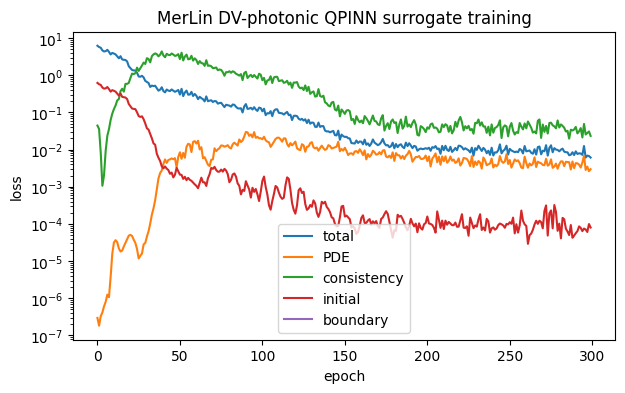

In [8]:
# Plot training losses
hist = np.array(history)
plt.figure(figsize=(7, 4))
plt.semilogy(hist[:, 0], label="total")
plt.semilogy(hist[:, 1], label="PDE")
plt.semilogy(hist[:, 2], label="consistency")
plt.semilogy(hist[:, 3], label="initial")
plt.semilogy(hist[:, 4], label="boundary")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("MerLin DV-photonic QPINN surrogate training")
plt.show()

## Evaluation

We evaluate the trained model on a uniform grid and compare it with the analytic solution using the relative L2 error:

$$
\frac{\lVert u_\theta-u_{\mathrm{exact}}\rVert_2}{\lVert u_{\mathrm{exact}}\rVert_2}.
$$


In [9]:
# Evaluate on a grid
nx, nt = 60, 60
x = torch.linspace(0, 1, nx, device=device, dtype=dtype).reshape(-1, 1)
t = torch.linspace(0, 1, nt, device=device, dtype=dtype).reshape(-1, 1)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")
xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

with torch.no_grad():
    U_pred, UX_hat = model(xt_grid)
    U_pred = U_pred.reshape(nx, nt).cpu()
    U_true = exact_u(xt_grid[:, 0:1], xt_grid[:, 1:2]).reshape(nx, nt).cpu()

rel_l2 = torch.linalg.norm(U_pred - U_true) / torch.linalg.norm(U_true)
print("relative L2 error:", float(rel_l2))

relative L2 error: 0.03725369647145271


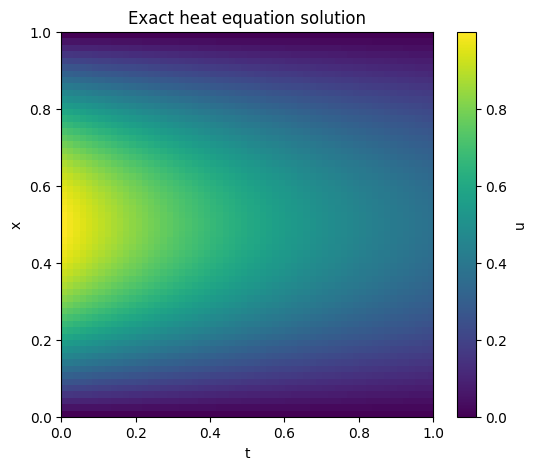

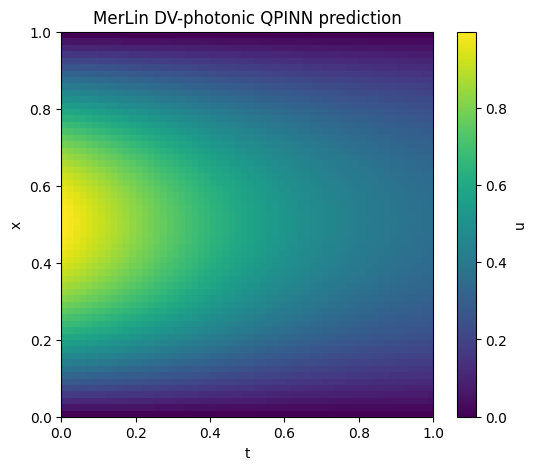

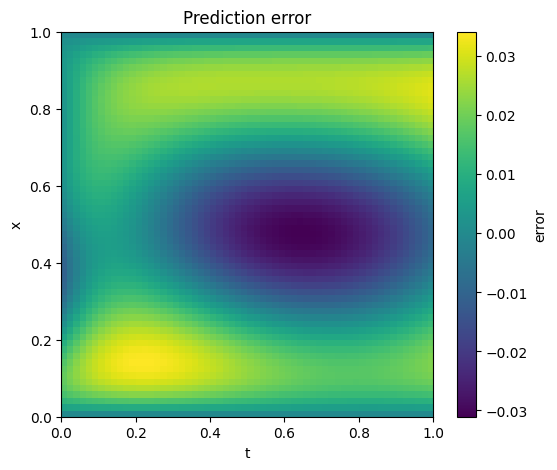

In [10]:
# Visual comparison
plt.figure(figsize=(6, 5))
plt.imshow(U_true.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Exact heat equation solution")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(U_pred.numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="u")
plt.xlabel("t")
plt.ylabel("x")
plt.title("MerLin DV-photonic QPINN prediction")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow((U_pred - U_true).numpy(), origin="lower", extent=[0, 1, 0, 1], aspect="auto")
plt.colorbar(label="error")
plt.xlabel("t")
plt.ylabel("x")
plt.title("Prediction error")
plt.show()

## Suggested ablations

This notebook is only the starting point. To test whether the quantum layer is useful, try controlled variants.

Replace the MerLin quantum layer with a classical MLP of comparable parameter count. If the MLP performs as well or better, there is no evidence that the quantum layer helps in this setting.

Freeze the MerLin quantum layer and train only the classical readout. If performance is similar to the fully trainable model, the learned quantum parameters may not be contributing much.

Remove the auxiliary derivative output and compute the second derivative directly with automatic differentiation. This tests whether the auxiliary derivative trick improves stability, speed, or accuracy.

Repeat each experiment over several random seeds. Report mean and standard deviation for relative L2 error, PDE residual, number of trainable parameters, and wall-clock training time.


## Extension to the Poisson equation

A natural second target is the one-dimensional Poisson equation:

$$
-u''(x)=f(x), \qquad x\in[0,1],
$$

with homogeneous Dirichlet boundary conditions:

$$
u(0)=u(1)=0.
$$

A convenient manufactured solution is:

$$
u(x)=\sin(\pi x),
$$

which gives:

$$
f(x)=\pi^2\sin(\pi x).
$$

To adapt this notebook, remove the time coordinate, sample only spatial points, and train the residual:

$$
r_f = -\partial_x\hat u_x - f(x),
$$

with the same consistency term:

$$
r_c=\partial_xu_\theta-\hat u_x.
$$

This gives a direct path from the heat-equation starter implementation to a Poisson-equation reproduction task.


## Notes for participants

This implementation is deliberately minimal. It is not intended to prove a quantum advantage. It is intended to give you a working MerLin-based QPINN baseline that you can reproduce, modify, and challenge.

Strong conclusions require fair comparisons. Use the same data, optimizer, training budget, and evaluation grid for the hybrid quantum-classical model and the classical baselines. The most valuable result may be a negative one if it is well controlled and clearly explained.
